In [45]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pyreadr
from tqdm import tqdm
from itertools import product

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.mixture import GaussianMixture
from sklearn.decomposition import PCA
from sklearn.pipeline import make_pipeline
from sklearn.metrics import silhouette_score, davies_bouldin_score, adjusted_rand_score
from sklearn.utils import resample
from kmedoids import KMedoids

import warnings
warnings.filterwarnings("ignore")

sns.set_theme()
scaler = StandardScaler()
DATA_PATH = os.path.join(os.getcwd(), 'data', 'prostate.rda')

In [46]:
data = pyreadr.read_r(DATA_PATH)
df_x = data['prostate.x'].astype('float64')
df_y = data['prostate.y'].astype('int32')

# Unsupervised clustering methods
## Internal Methods of evaluating clusters

In [47]:
methods = {
    'K-Means': lambda **kw: KMeans(**kw),
    'AGNES (avg linkage)': lambda **kw: AgglomerativeClustering(linkage='average', **kw),
    'AGNES (complete)': lambda **kw: AgglomerativeClustering(linkage='complete', **kw),
    'AGNES (single)': lambda **kw: AgglomerativeClustering(linkage='single', **kw),
    'Gaussian Mixture (diagonal)': lambda **kw: GaussianMixture(covariance_type='diag', **kw),
    'Gaussian Mixture (spherical)': lambda **kw: GaussianMixture(covariance_type='spherical', **kw),
}

def calculate_purity(y_true, y_pred):
    """Calculates the purity score for clustering."""
    if len(y_true) == 0 or len(y_pred) == 0:
        return 0.0

    total_correct = 0
    unique_clusters = np.unique(y_pred)

    for cluster_id in unique_clusters:
        true_labels_in_cluster = y_true[y_pred == cluster_id]

        if len(true_labels_in_cluster) == 0:
            continue

        if len(true_labels_in_cluster) > 0:
            majority_class_count = np.bincount(true_labels_in_cluster).max()
            total_correct += majority_class_count
    
    return total_correct / len(y_true)

def clusterization(n_bootstraps, n_clusters):
    idx = pd.MultiIndex.from_product(
        [list(methods.keys()), range(n_bootstraps), range(2, n_clusters)],
        names=['method', 'bootstrap', 'n_clusters']
    )
    columns = ['sil', 'dbi', 'ari', 'pur']
    results = pd.DataFrame(index=idx, columns=columns)

    for i in tqdm(range(n_bootstraps), desc='Bootstraps'):
        sample_indices = resample(df_x.index, replace=True, random_state=i)
        Xb_scaled = scaler.fit_transform(df_x.loc[sample_indices])
        y_true = df_y.loc[sample_indices].values.flatten()
        
        for method_name, method in methods.items():
            for k in range(2, n_clusters):
                if 'Gaussian Mixture' in method_name:
                    model = method(n_components=k)
                else:
                    model = method(n_clusters=k)
                labels = model.fit_predict(Xb_scaled)

                # Internal Metrics
                sil = silhouette_score(Xb_scaled, labels)
                db = davies_bouldin_score(Xb_scaled, labels)
                # External Metrics
                ari = adjusted_rand_score(y_true, labels)
                pur = calculate_purity(y_true, labels)
                
                scores_list = [sil, db, ari, pur]
                results.loc[(method_name, i, k), :] = scores_list
    return results

def plot_results(results, plot_title_internal, plot_title_external):
    # Internal Index Metrics plot
    sil_means = results['sil'].unstack('method')
    dbi_means = results['dbi'].unstack('method')
    ari_means = results['ari'].unstack('method')
    pur_means = results['pur'].unstack('method')

    sil_means = sil_means.groupby(level='n_clusters').mean()
    dbi_means = dbi_means.groupby(level='n_clusters').mean()
    ari_means = ari_means.groupby(level='n_clusters').mean()
    pur_means = pur_means.groupby(level='n_clusters').mean()

    fig, ax = plt.subplots(1,2, figsize=(15,6))
    fig.suptitle(plot_title_internal)

    for method_name in methods:
        if method_name == 'DBSCAN':
            continue
        ax[0].plot(sil_means.index, sil_means[method_name], label=method_name, marker='o')
        ax[0].set_title(r'Silhouette Index')
        ax[0].set_xlabel(r'$k$')
        ax[0].set_ylabel('Silhouette')
        
        ax[1].plot(dbi_means.index, dbi_means[method_name], label=method_name, marker='o')
        ax[1].set_title('Davies-Bouldin Index')
        ax[1].set_xlabel(r'$k$')
        ax[1].set_ylabel('DB score')
        
    plt.legend()
    plt.show()
    
    # External Index Metrics plot
    fig, ax = plt.subplots(1,2, figsize=(15,6))
    fig.suptitle(plot_title_external)

    for method_name in methods:
        if method_name == 'DBSCAN':
            continue
        ax[0].plot(ari_means.index, ari_means[method_name], label=method_name, marker='o')
        ax[0].set_title(r'Adjusted Rand Index')
        ax[0].set_xlabel(r'$k$')
        ax[0].set_ylabel('ARI Score')
        
        ax[1].plot(pur_means.index, pur_means[method_name], label=method_name, marker='o')
        ax[1].set_title('Purity Score')
        ax[1].set_xlabel(r'$k$')
        ax[1].set_ylabel('Purity')
        
    plt.legend()
    plt.show()

Bootstraps: 100%|██████████| 50/50 [03:09<00:00,  3.80s/it]


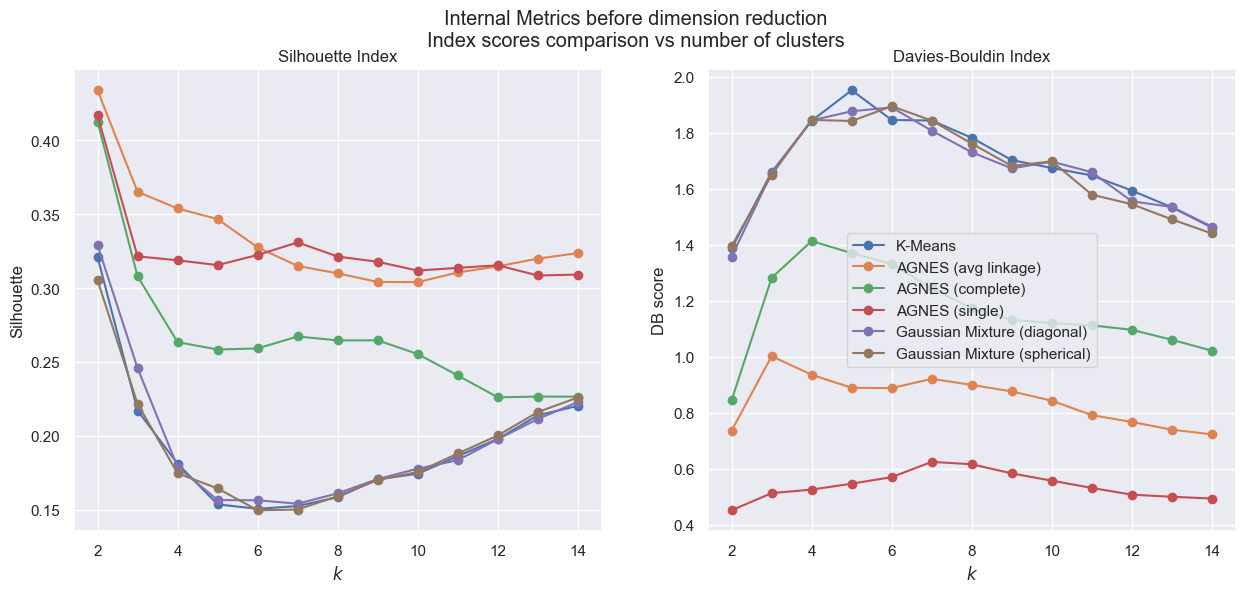

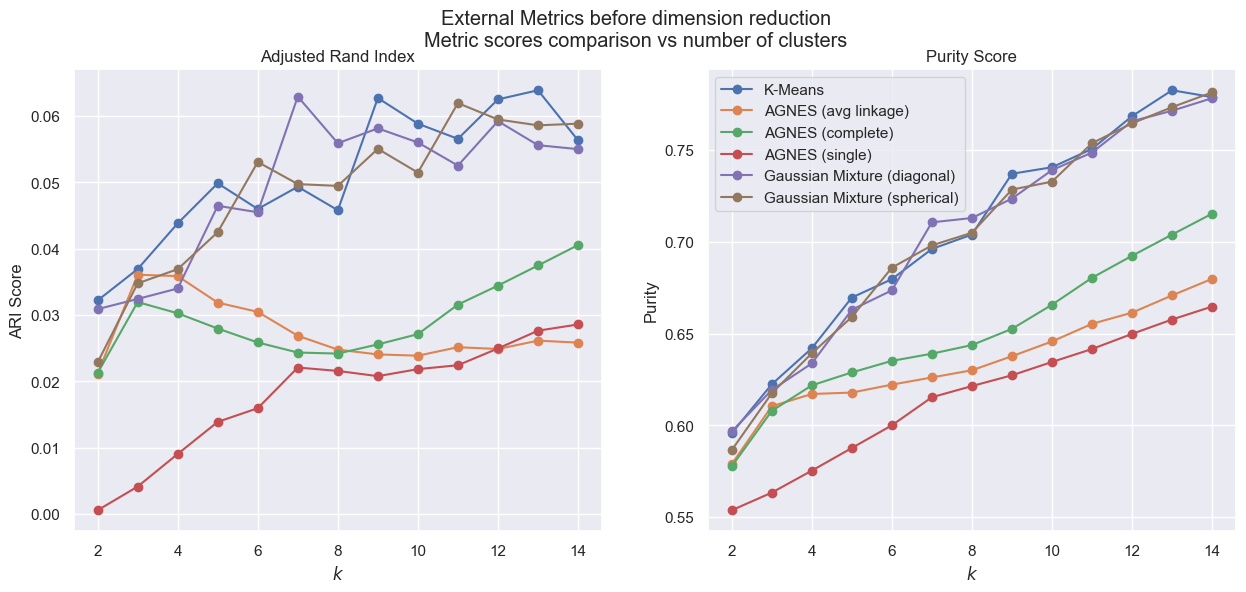

In [48]:
n_bootstraps = 50
n_clusters = 15
title_int = 'Internal Metrics before dimension reduction\nIndex scores comparison vs number of clusters'
title_ext = 'External Metrics before dimension reduction\nMetric scores comparison vs number of clusters'

results = clusterization(n_bootstraps, n_clusters)
plot_results(results, title_int, title_ext)

# PCA + Clustering
## PCA evaluation

In [49]:
scaled_X = scaler.fit_transform(df_x)
n_bootstraps = 50
n_components = 50
variances = []

for i in tqdm(range(n_bootstraps), desc='Bootstraps'):
    Xb = resample(scaled_X, replace=True, random_state=i)
    pca = PCA(n_components=n_components)
    pca.fit(Xb)
    variances.append(pca.explained_variance_ratio_)

variances = np.array(variances)

Bootstraps: 100%|██████████| 50/50 [00:04<00:00, 10.85it/s]


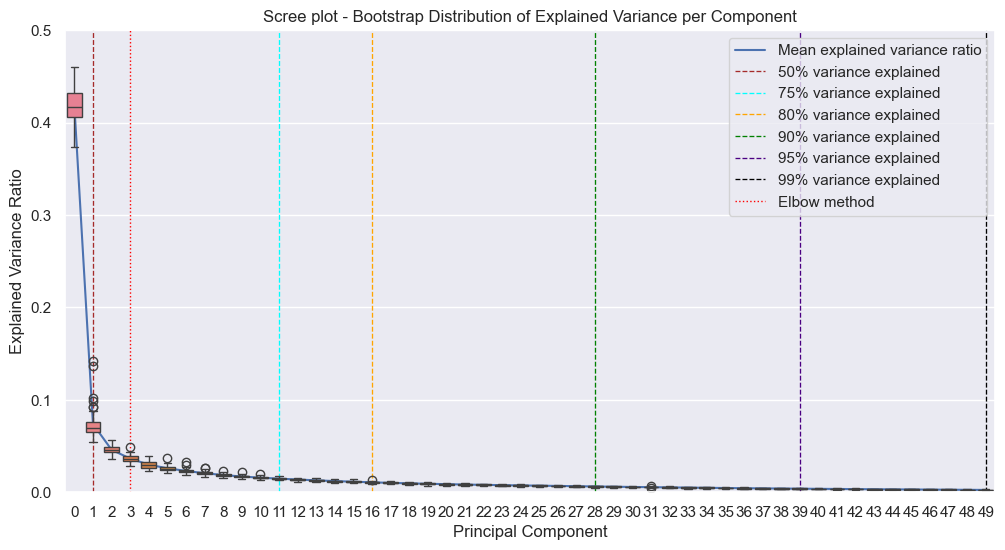

In [50]:
mean_variances = variances.mean(axis=0)
cum_variance = np.cumsum(mean_variances)

percentiles = np.array([0.5, 0.75, 0.8, 0.9, 0.95, 0.99])
n_comp_percentiles = np.searchsorted(cum_variance, percentiles) - 1

plt.figure(figsize=(12,6))
plt.plot(range(variances.shape[1]), variances.mean(axis=0), label='Mean explained variance ratio')
for idx, color, perc in zip(n_comp_percentiles, ['brown', 'cyan', 'orange', 'green', 'indigo', 'black'], percentiles):
    plt.vlines(idx, 0, 0.5, ls='--', lw=0.95, color=color, label=f'{int(perc*100)}% variance explained')
plt.vlines(3, 0, 0.5, ls=':', lw=1, color='red', label='Elbow method')
sns.boxplot(variances)
plt.title('Scree plot - Bootstrap Distribution of Explained Variance per Component')
plt.xlabel('Principal Component')
plt.ylabel('Explained Variance Ratio')
plt.legend()
plt.ylim((0, 0.5))
plt.show()

## Clustering

In [51]:
def clusterization_with_PCA(n_boostraps, n_clusters, n_components_pca):
    idx = pd.MultiIndex.from_product(
        [list(methods.keys()), range(n_bootstraps), range(2, n_clusters)],
        names=['method', 'bootstrap', 'n_clusters']
    )
    columns = ['sil', 'dbi', 'ari', 'pur']
    results = pd.DataFrame(index=idx, columns=columns)


    for i in tqdm(range(n_bootstraps), desc='Bootstraps'):
        sample_indices = resample(df_x.index, replace=True, random_state=i)
        Xb_scaled = scaler.fit_transform(df_x.loc[sample_indices])
        y_true = df_y.loc[sample_indices].values.flatten()
        
        pca = PCA(n_components=n_components_pca, random_state=42)
        Xb_pca = pca.fit_transform(Xb_scaled)
        
        for method_name, method in methods.items():
            for k in range(2, n_clusters):
                if 'Gaussian Mixture' in method_name:
                    model = method(n_components=k)
                else:
                    model = method(n_clusters=k)
                labels = model.fit_predict(Xb_pca)

                # Internal Metrics
                sil = silhouette_score(Xb_pca, labels)
                db = davies_bouldin_score(Xb_pca, labels)
                # External Metrics
                ari = adjusted_rand_score(y_true, labels)
                pur = calculate_purity(y_true, labels)
                
                scores_list = [sil, db, ari, pur]
                results.loc[(method_name, i, k), :] = scores_list
    
    return results

# 50% of variance explained (2D)

Bootstraps: 100%|██████████| 50/50 [00:22<00:00,  2.27it/s]


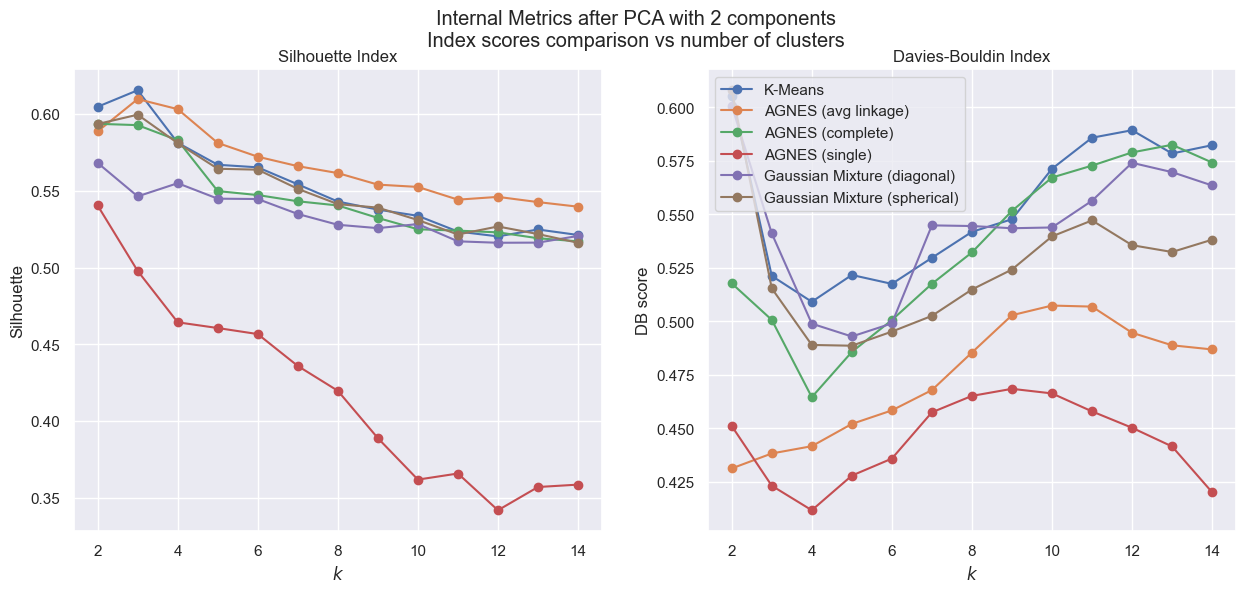

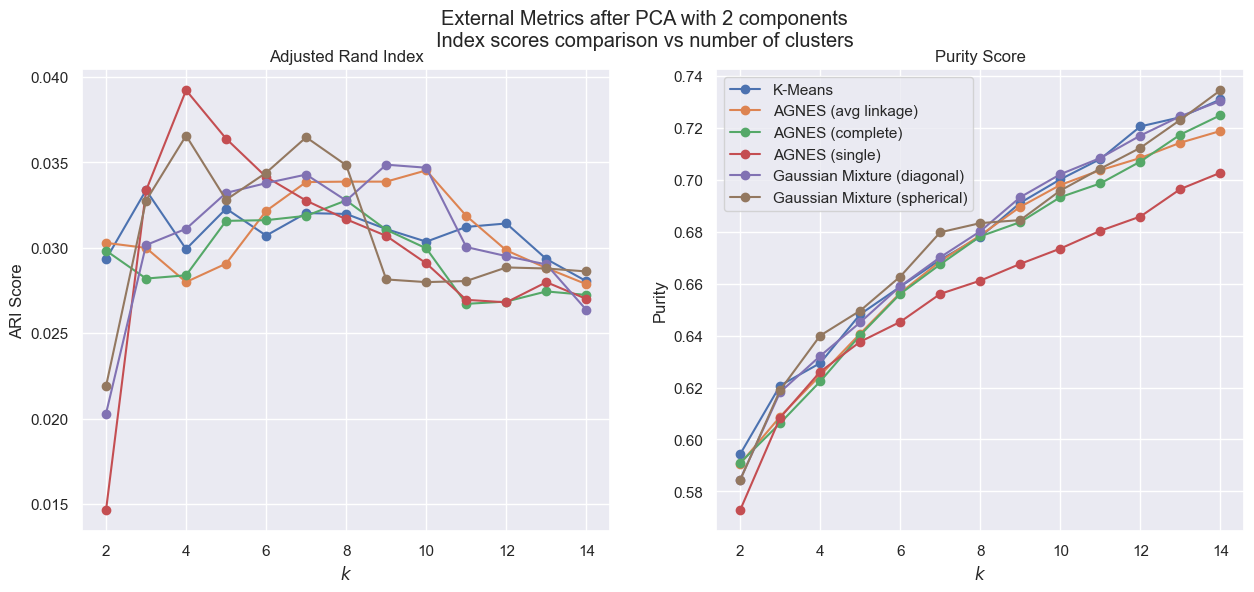

In [52]:
n_bootstraps = 50
n_clusters = 15
n_components_pca = 2
title_int = f'Internal Metrics after PCA with {n_components_pca} components\nIndex scores comparison vs number of clusters'
title_ext = f'External Metrics after PCA with {n_components_pca} components\nIndex scores comparison vs number of clusters'

results = clusterization_with_PCA(n_bootstraps, n_clusters, n_components_pca)
plot_results(results, title_int, title_ext)

# $\approx 57,39$ of variance explained (4D - 4 components)

Bootstraps: 100%|██████████| 50/50 [00:21<00:00,  2.33it/s]


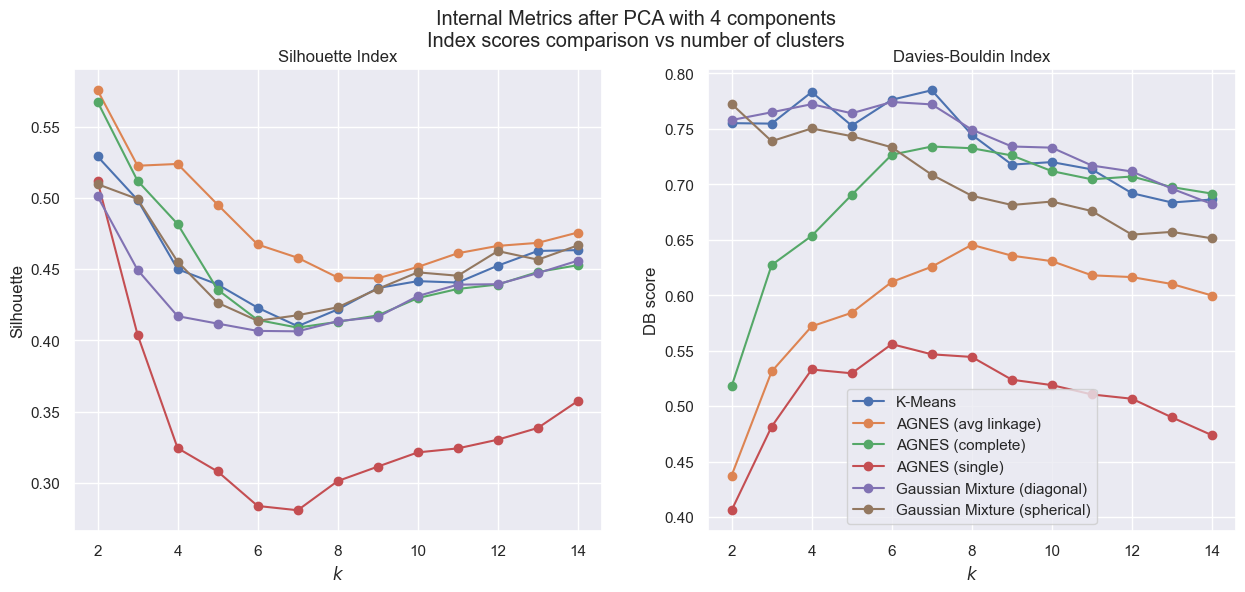

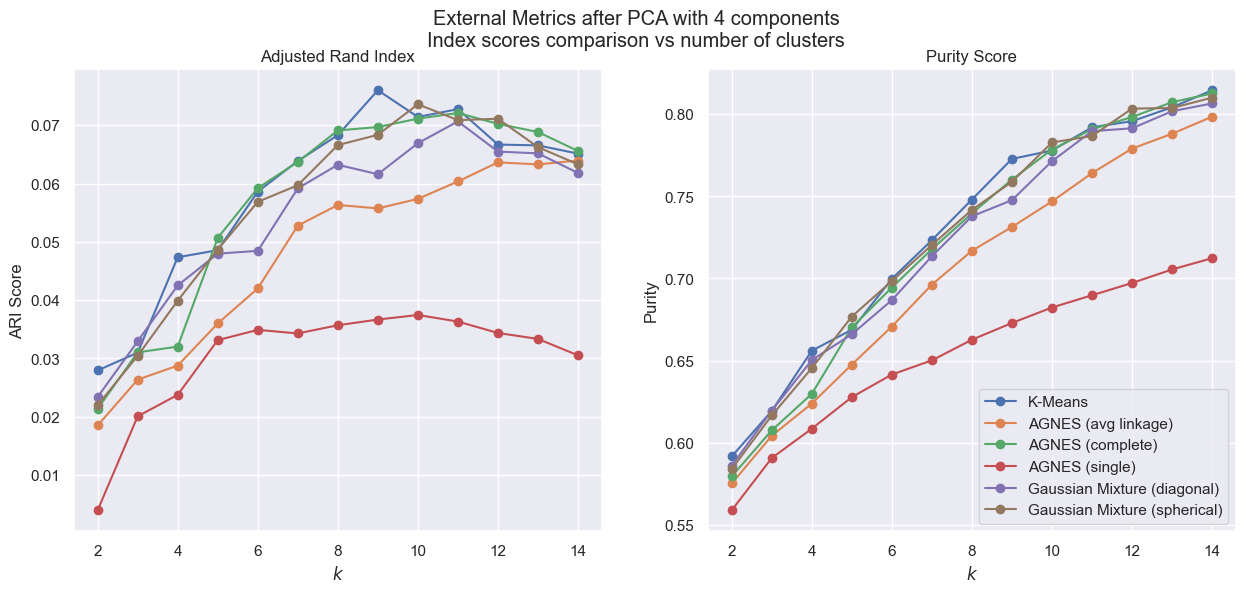

In [53]:
n_bootstraps = 50
n_clusters = 15
n_components_pca = 4
title_int = f'Internal Metrics after PCA with {n_components_pca} components\nIndex scores comparison vs number of clusters'
title_ext = f'External Metrics after PCA with {n_components_pca} components\nIndex scores comparison vs number of clusters'

results = clusterization_with_PCA(n_bootstraps, n_clusters, n_components_pca)
plot_results(results, title_int, title_ext)

# 80% of variance explained (17D - 17 components PCA)

Bootstraps: 100%|██████████| 50/50 [00:22<00:00,  2.21it/s]


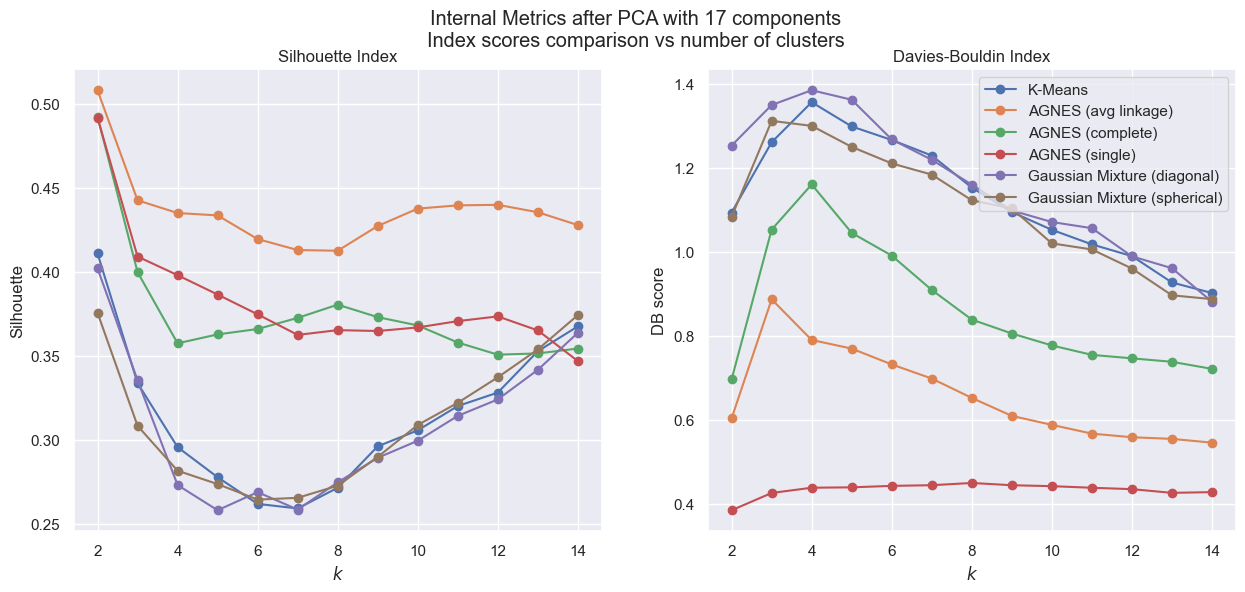

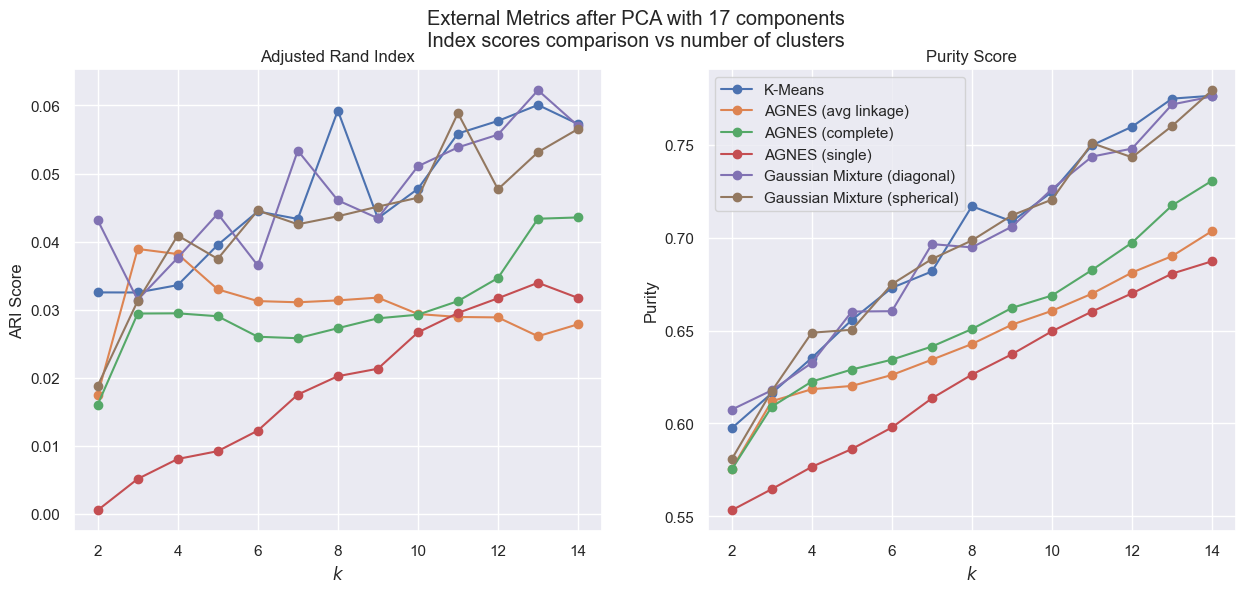

In [54]:
n_bootstraps = 50
n_clusters = 15
n_components_pca = 17
title_int = f'Internal Metrics after PCA with {n_components_pca} components\nIndex scores comparison vs number of clusters'
title_ext = f'External Metrics after PCA with {n_components_pca} components\nIndex scores comparison vs number of clusters'

results = clusterization_with_PCA(n_bootstraps, n_clusters, n_components_pca)
plot_results(results, title_int, title_ext)

# SVMs